# Windowing Strategy Comparison

This notebook compares different windowing strategies on the same dataset.

In [3]:
import sys
sys.path.append('../..')

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from log_anomaly_analysis import ModularPipeline

plt.style.use('seaborn-v0_8')
%matplotlib inline

## Compare Different Windowing Strategies

In [4]:
configs = {
    'Fixed': '../../configs/apache/basic.yaml',
    'Sliding': '../../configs/apache/sliding.yaml',
    'Session': '../../configs/apache/session.yaml',
    'Adaptive': '../../configs/apache/adaptive.yaml'
}

results_comparison = {}

for strategy, config_path in configs.items():
    print(f"Running {strategy} windowing...")
    pipeline = ModularPipeline(config_path)
    results, summary = pipeline.run()
    results_comparison[strategy] = {
        'results': results,
        'summary': summary
    }
    print(f"{strategy}: {summary['total_windows']} windows, {summary['anomalous_windows']} anomalies")

2025-09-17 02:08:13.065 | INFO     | log_anomaly_analysis.core.pipeline:_initialize_components:40 - Initializing pipeline components
2025-09-17 02:08:13.067 | INFO     | log_anomaly_analysis.core.pipeline:__init__:36 - Pipeline initialized with output directory: /home/mih/cs/elfak/diplomski/log-anomaly-analysis/data/results/apache_basic/20250917-020813
2025-09-17 02:08:13.067 | INFO     | log_anomaly_analysis.core.pipeline:run:52 - Starting modular anomaly detection pipeline
2025-09-17 02:08:13.068 | INFO     | log_anomaly_analysis.core.pipeline:run:57 - Loading dataset...
2025-09-17 02:08:13.068 | INFO     | log_anomaly_analysis.datasets.loaders:load_dataset:18 - Loading dataset from /home/mih/cs/elfak/diplomski/log-anomaly-analysis/data/raw/loghub_2k/Apache/Apache_2k.log
2025-09-17 02:08:13.070 | INFO     | log_anomaly_analysis.datasets.loaders:_load_file_dataset:40 - Loaded 2000 raw log lines
2025-09-17 02:08:13.074 | INFO     | log_anomaly_analysis.core.pipeline:run:59 - Loaded 200

Running Fixed windowing...
Fixed: 178 windows, 4 anomalies
Running Sliding windowing...


2025-09-17 02:08:13.263 | INFO     | log_anomaly_analysis.core.pipeline:run:72 - Extracting templates...
2025-09-17 02:08:13.322 | INFO     | log_anomaly_analysis.core.components.parsing:process:115 - Extracted 5 unique templates from 2000 logs
2025-09-17 02:08:13.323 | INFO     | log_anomaly_analysis.core.pipeline:run:74 - Extracted templates for 2000 logs
2025-09-17 02:08:13.324 | INFO     | log_anomaly_analysis.core.pipeline:run:82 - Creating windows...
2025-09-17 02:08:13.324 | INFO     | log_anomaly_analysis.core.components.windowing:process:32 - Applying sliding windowing strategy
2025-09-17 02:08:13.486 | INFO     | log_anomaly_analysis.core.pipeline:run:84 - Created 425 windows
2025-09-17 02:08:13.486 | INFO     | log_anomaly_analysis.core.pipeline:run:92 - Building event count matrix...
2025-09-17 02:08:13.487 | INFO     | log_anomaly_analysis.core.components.event_matrix:process:24 - Creating event count matrix from windowed data
2025-09-17 02:08:13.501 | INFO     | log_anoma

Sliding: 425 windows, 11 anomalies
Running Session windowing...
Session: 34 windows, 1 anomalies
Running Adaptive windowing...


2025-09-17 02:08:13.798 | INFO     | log_anomaly_analysis.core.components.parsing:process:115 - Extracted 5 unique templates from 2000 logs
2025-09-17 02:08:13.800 | INFO     | log_anomaly_analysis.core.pipeline:run:74 - Extracted templates for 2000 logs
2025-09-17 02:08:13.800 | INFO     | log_anomaly_analysis.core.pipeline:run:82 - Creating windows...
2025-09-17 02:08:13.801 | INFO     | log_anomaly_analysis.core.components.windowing:process:32 - Applying adaptive windowing strategy
2025-09-17 02:08:13.823 | INFO     | log_anomaly_analysis.core.pipeline:run:84 - Created 98 windows
2025-09-17 02:08:13.823 | INFO     | log_anomaly_analysis.core.pipeline:run:92 - Building event count matrix...
2025-09-17 02:08:13.824 | INFO     | log_anomaly_analysis.core.components.event_matrix:process:24 - Creating event count matrix from windowed data
2025-09-17 02:08:13.833 | INFO     | log_anomaly_analysis.core.components.event_matrix:process:76 - Created event matrix with shape: (98, 10)
2025-09-1

Adaptive: 98 windows, 3 anomalies


## Comparison Plots

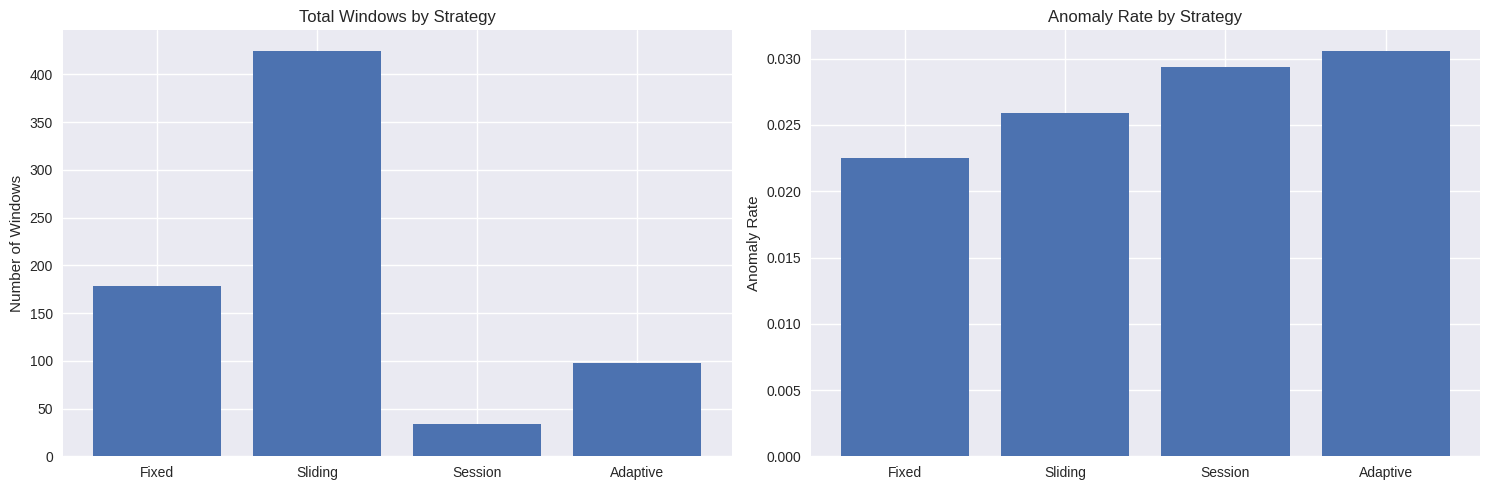

In [5]:
# Compare window counts and anomaly rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

strategies = list(results_comparison.keys())
window_counts = [results_comparison[s]['summary']['total_windows'] for s in strategies]
anomaly_rates = [results_comparison[s]['summary']['anomaly_rate'] for s in strategies]

ax1.bar(strategies, window_counts)
ax1.set_title('Total Windows by Strategy')
ax1.set_ylabel('Number of Windows')

ax2.bar(strategies, anomaly_rates)
ax2.set_title('Anomaly Rate by Strategy')
ax2.set_ylabel('Anomaly Rate')

plt.tight_layout()
plt.show()